# Section 2 — Listed CLO closed-end funds: the sentiment gauge

Thin driver notebook: all logic lives in `src/cef/`.

- **Prices**: full history via yfinance.
- **NAV proxy**: these tickers are classified as plain equity on Yahoo, so `navPrice` (which worked for Section 1's ETFs) isn't populated — `bookValue` is used instead, clearly labeled as a quarterly accounting proxy, not the funds' own monthly NAV estimates.
- **Distributions**: full real dividend history via yfinance — the strongest exhibit in this section, no data-availability caveats.
- **Portfolio**: SEC EDGAR NPORT-P filings (structured XML), not the HTML N-CSR tables the mission brief suggested — more reliable, same underlying disclosure. CLO positions are tagged by the `assetCat == "ABS-CBDO"` field where present, with a name/title regex fallback for filers (e.g. OXLC) that leave it blank.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.cef import (
    scrape_prices_nav, scrape_filings,
    analysis_premium_discount, analysis_distributions, analysis_portfolio, analysis_equity_beta,
    viz_sentiment, viz_navprice, viz_portfolio,
)

/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_prices_nav.run()
    scrape_filings.run()

## Analysis (interim -> final)

In [3]:
premium_discount = analysis_premium_discount.run()
distributions = analysis_distributions.run()
portfolio = analysis_portfolio.run()
equity_beta = analysis_equity_beta.run()

book-value history has only 1 distinct date(s); need ~30 for a stable vol ratio. Run scrape_prices_nav.py again on more days.


## Viz (final -> figures/)

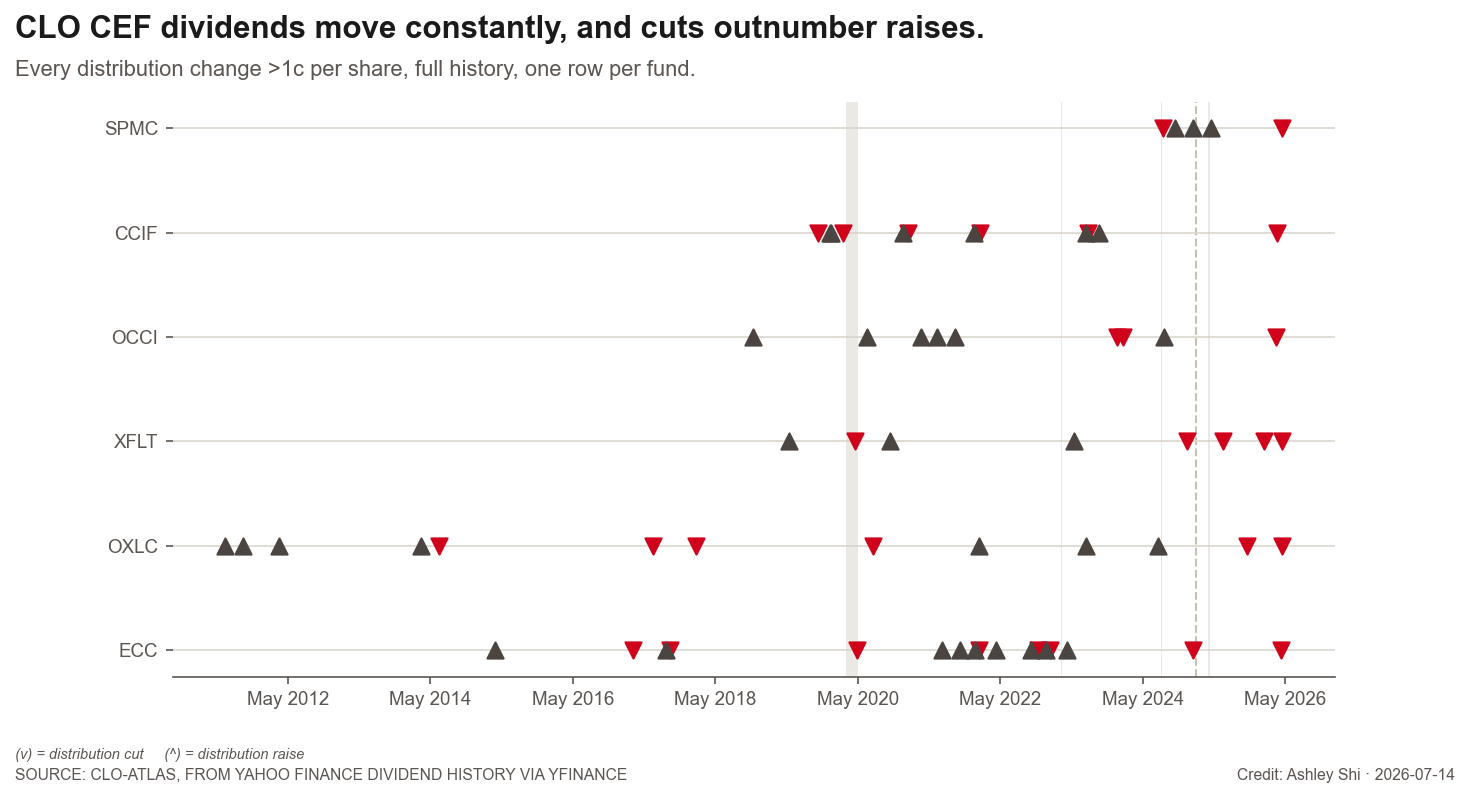

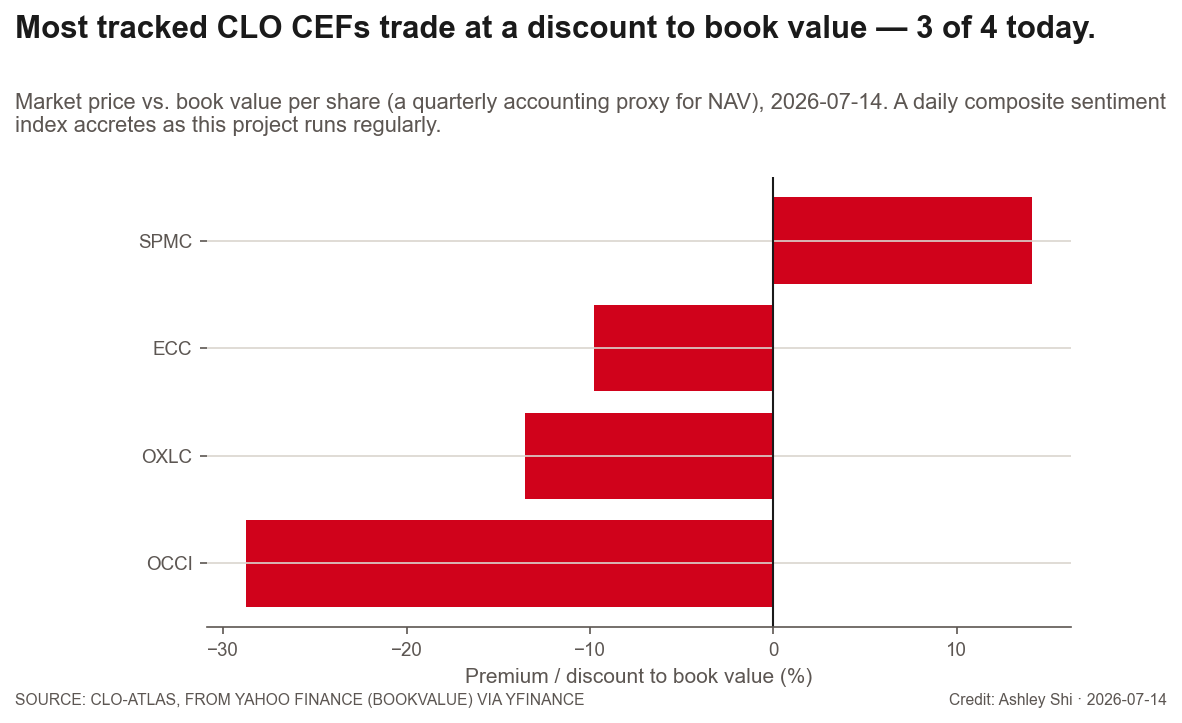

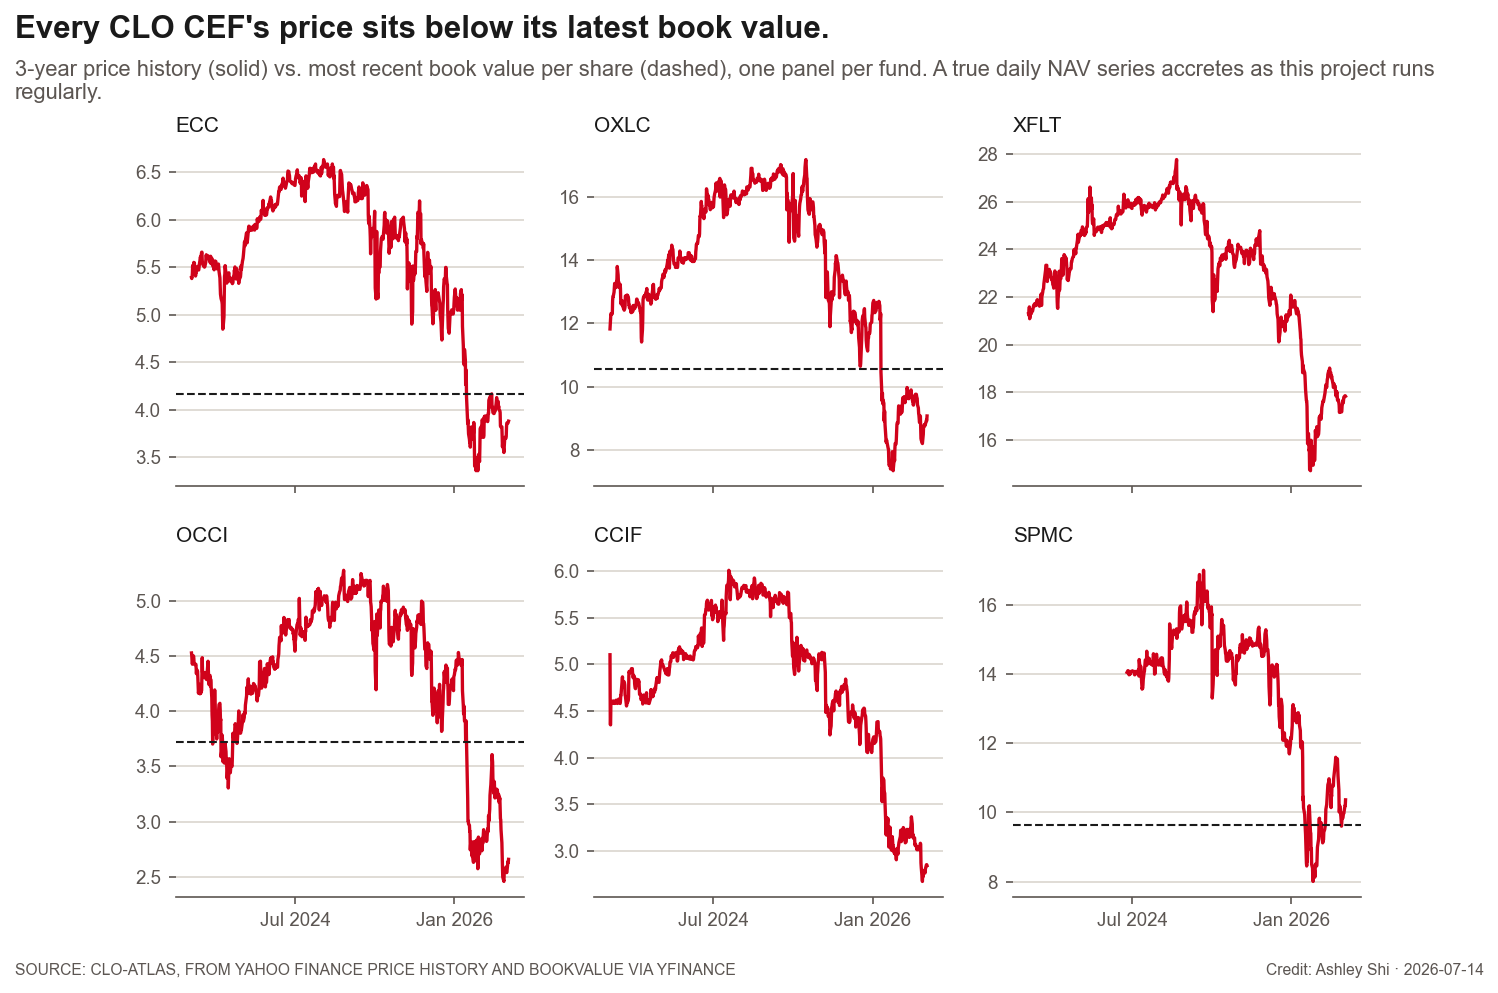

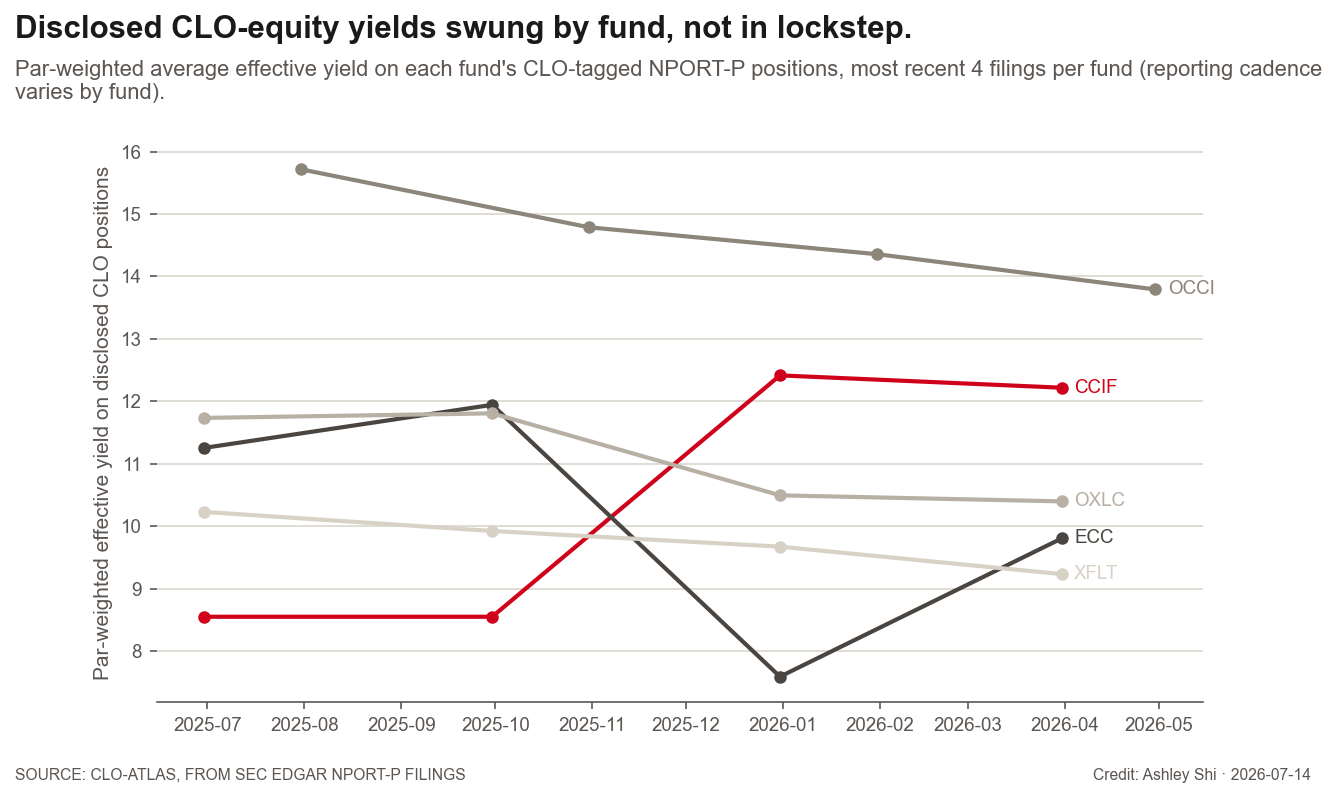

In [4]:
viz_sentiment.run()
viz_navprice.run()
viz_portfolio.run()

## Exhibits

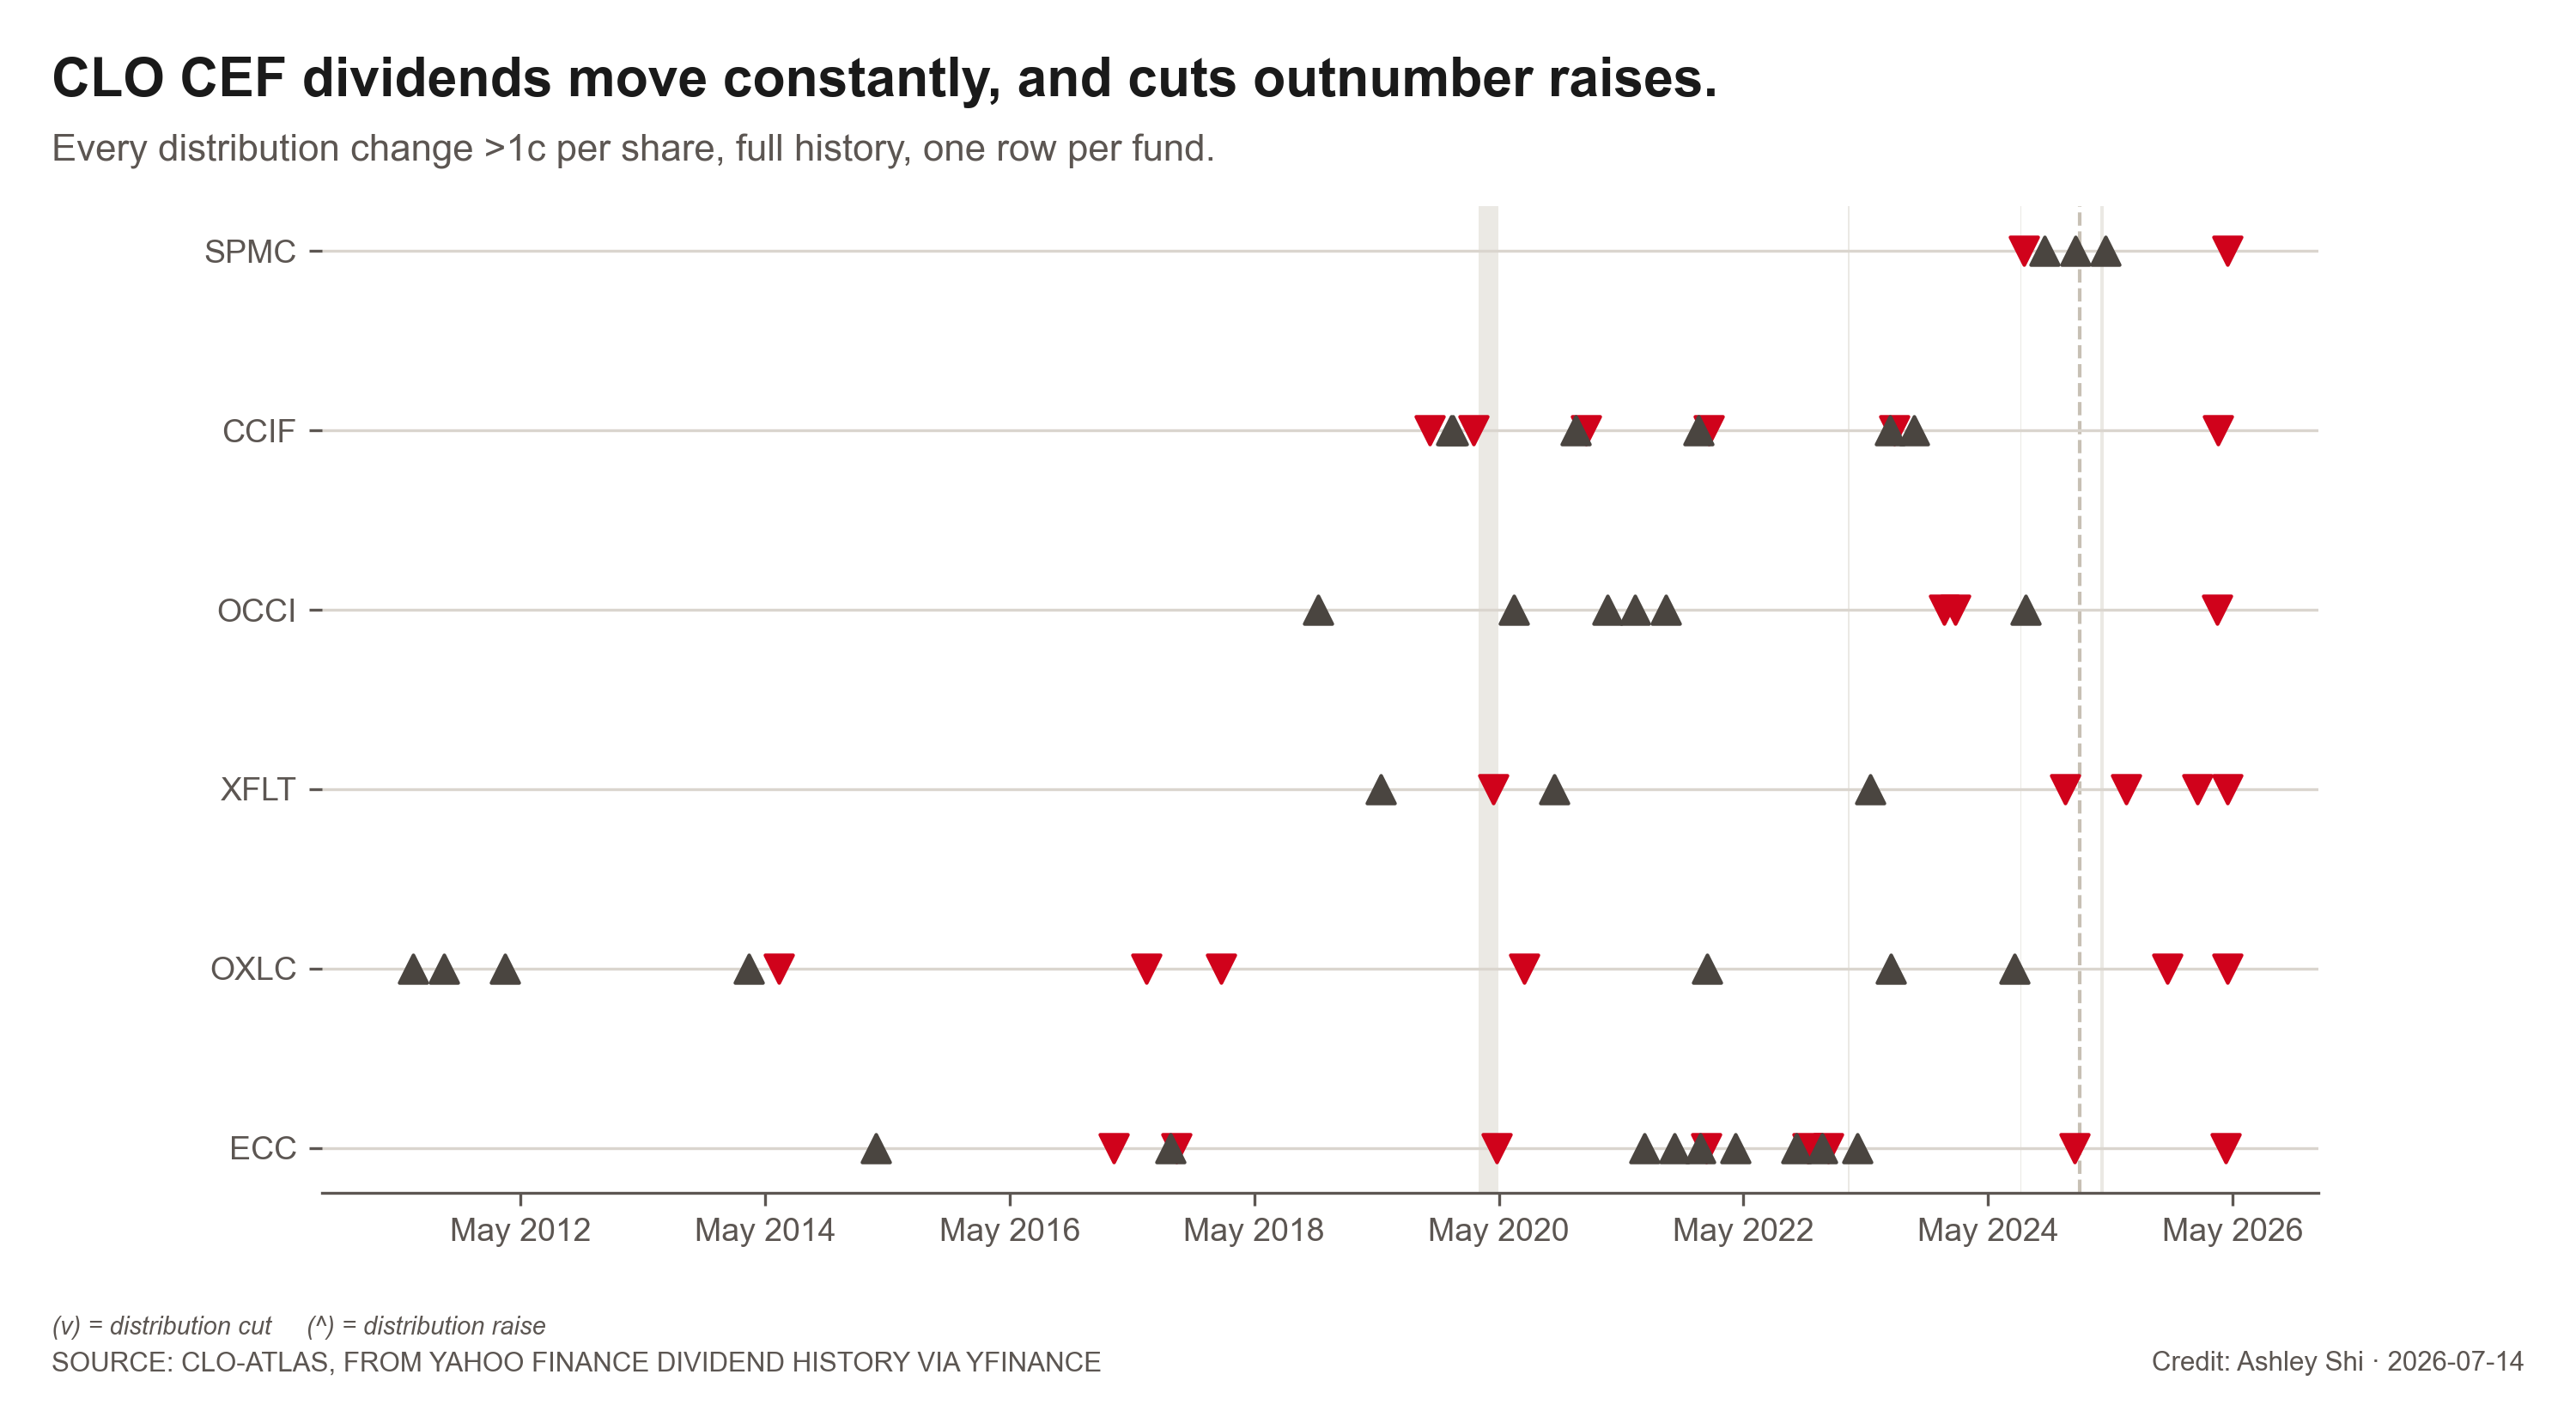

In [5]:
path = pathlib.Path("../figures") / "viz_distribution_changes.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_distribution_changes")


**VERIFIED**: every distribution change greater than 1c/share for all six tracked CLO CEFs (ECC, OXLC, XFLT, OCCI, CCIF, SPMC), from full real dividend history via Yahoo Finance — the one exhibit in this section with no data-availability caveat. The chart timelines each cut (marked v) and raise (marked ^) against the macro event flags, and cuts visibly outnumber raises across the tracked history. For a reader meeting CLO CEFs for the first time, this is the plainest evidence that the double-digit yields these funds advertise are not a fixed coupon — they get trimmed more often than they get raised, which is the first thing to know before treating the yield as free money.

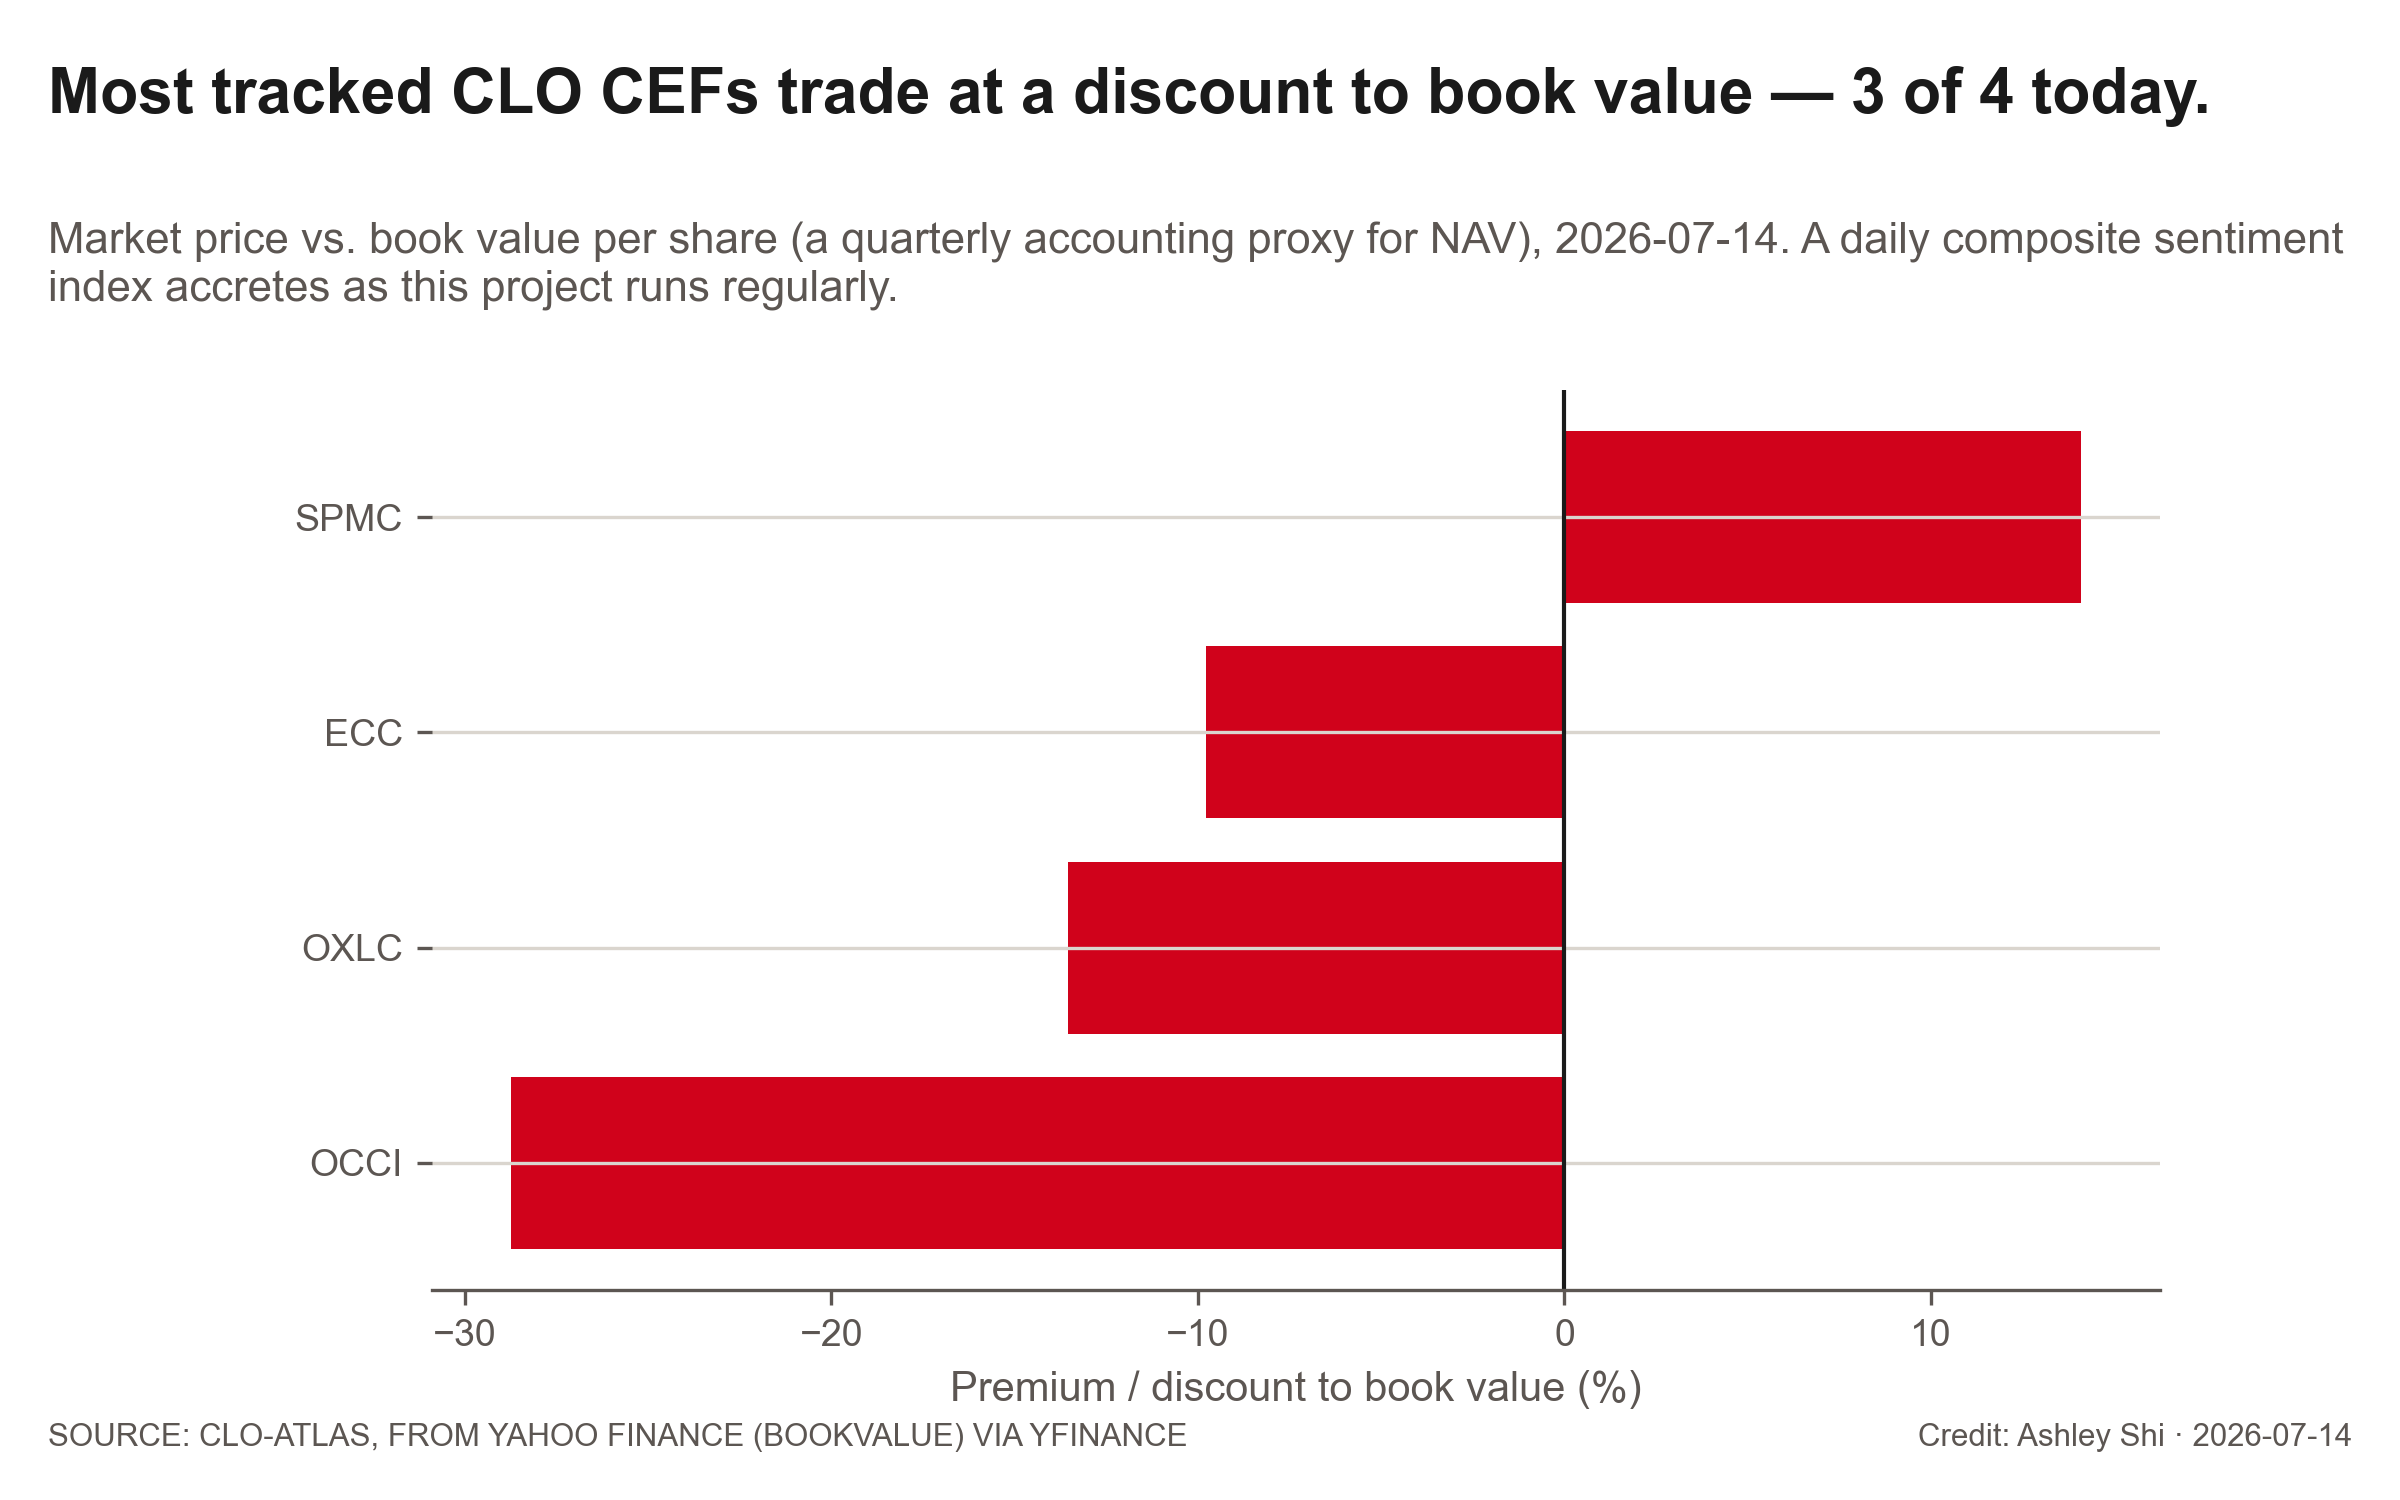

In [6]:
path = pathlib.Path("../figures") / "viz_current_discount_snapshot.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_current_discount_snapshot")


**VERIFIED**, with a labeled proxy caveat: book value per share via Yahoo Finance's `bookValue` field, a quarterly accounting figure standing in for these funds' own more frequent NAV estimates (the tickers are classified as plain equity on Yahoo, not funds, so `navPrice` isn't populated). The horizontal bar chart ranks the four CLO CEFs with a usable book-value reading on the latest date (SPMC, ECC, OXLC, OCCI — XFLT and CCIF drop out here for missing `bookValue` data, not excluded on purpose) by premium/discount to that book value, with the zero line marking parity. It's the cross-sectional companion to the flywheel exhibit in the Oxford Lane deep-dive: most of the CEF universe trades at a discount to book even while OXLC alone has traded at a persistent premium, which is exactly the divergence that makes OXLC's ATM-issuance story a special case rather than the sector norm.

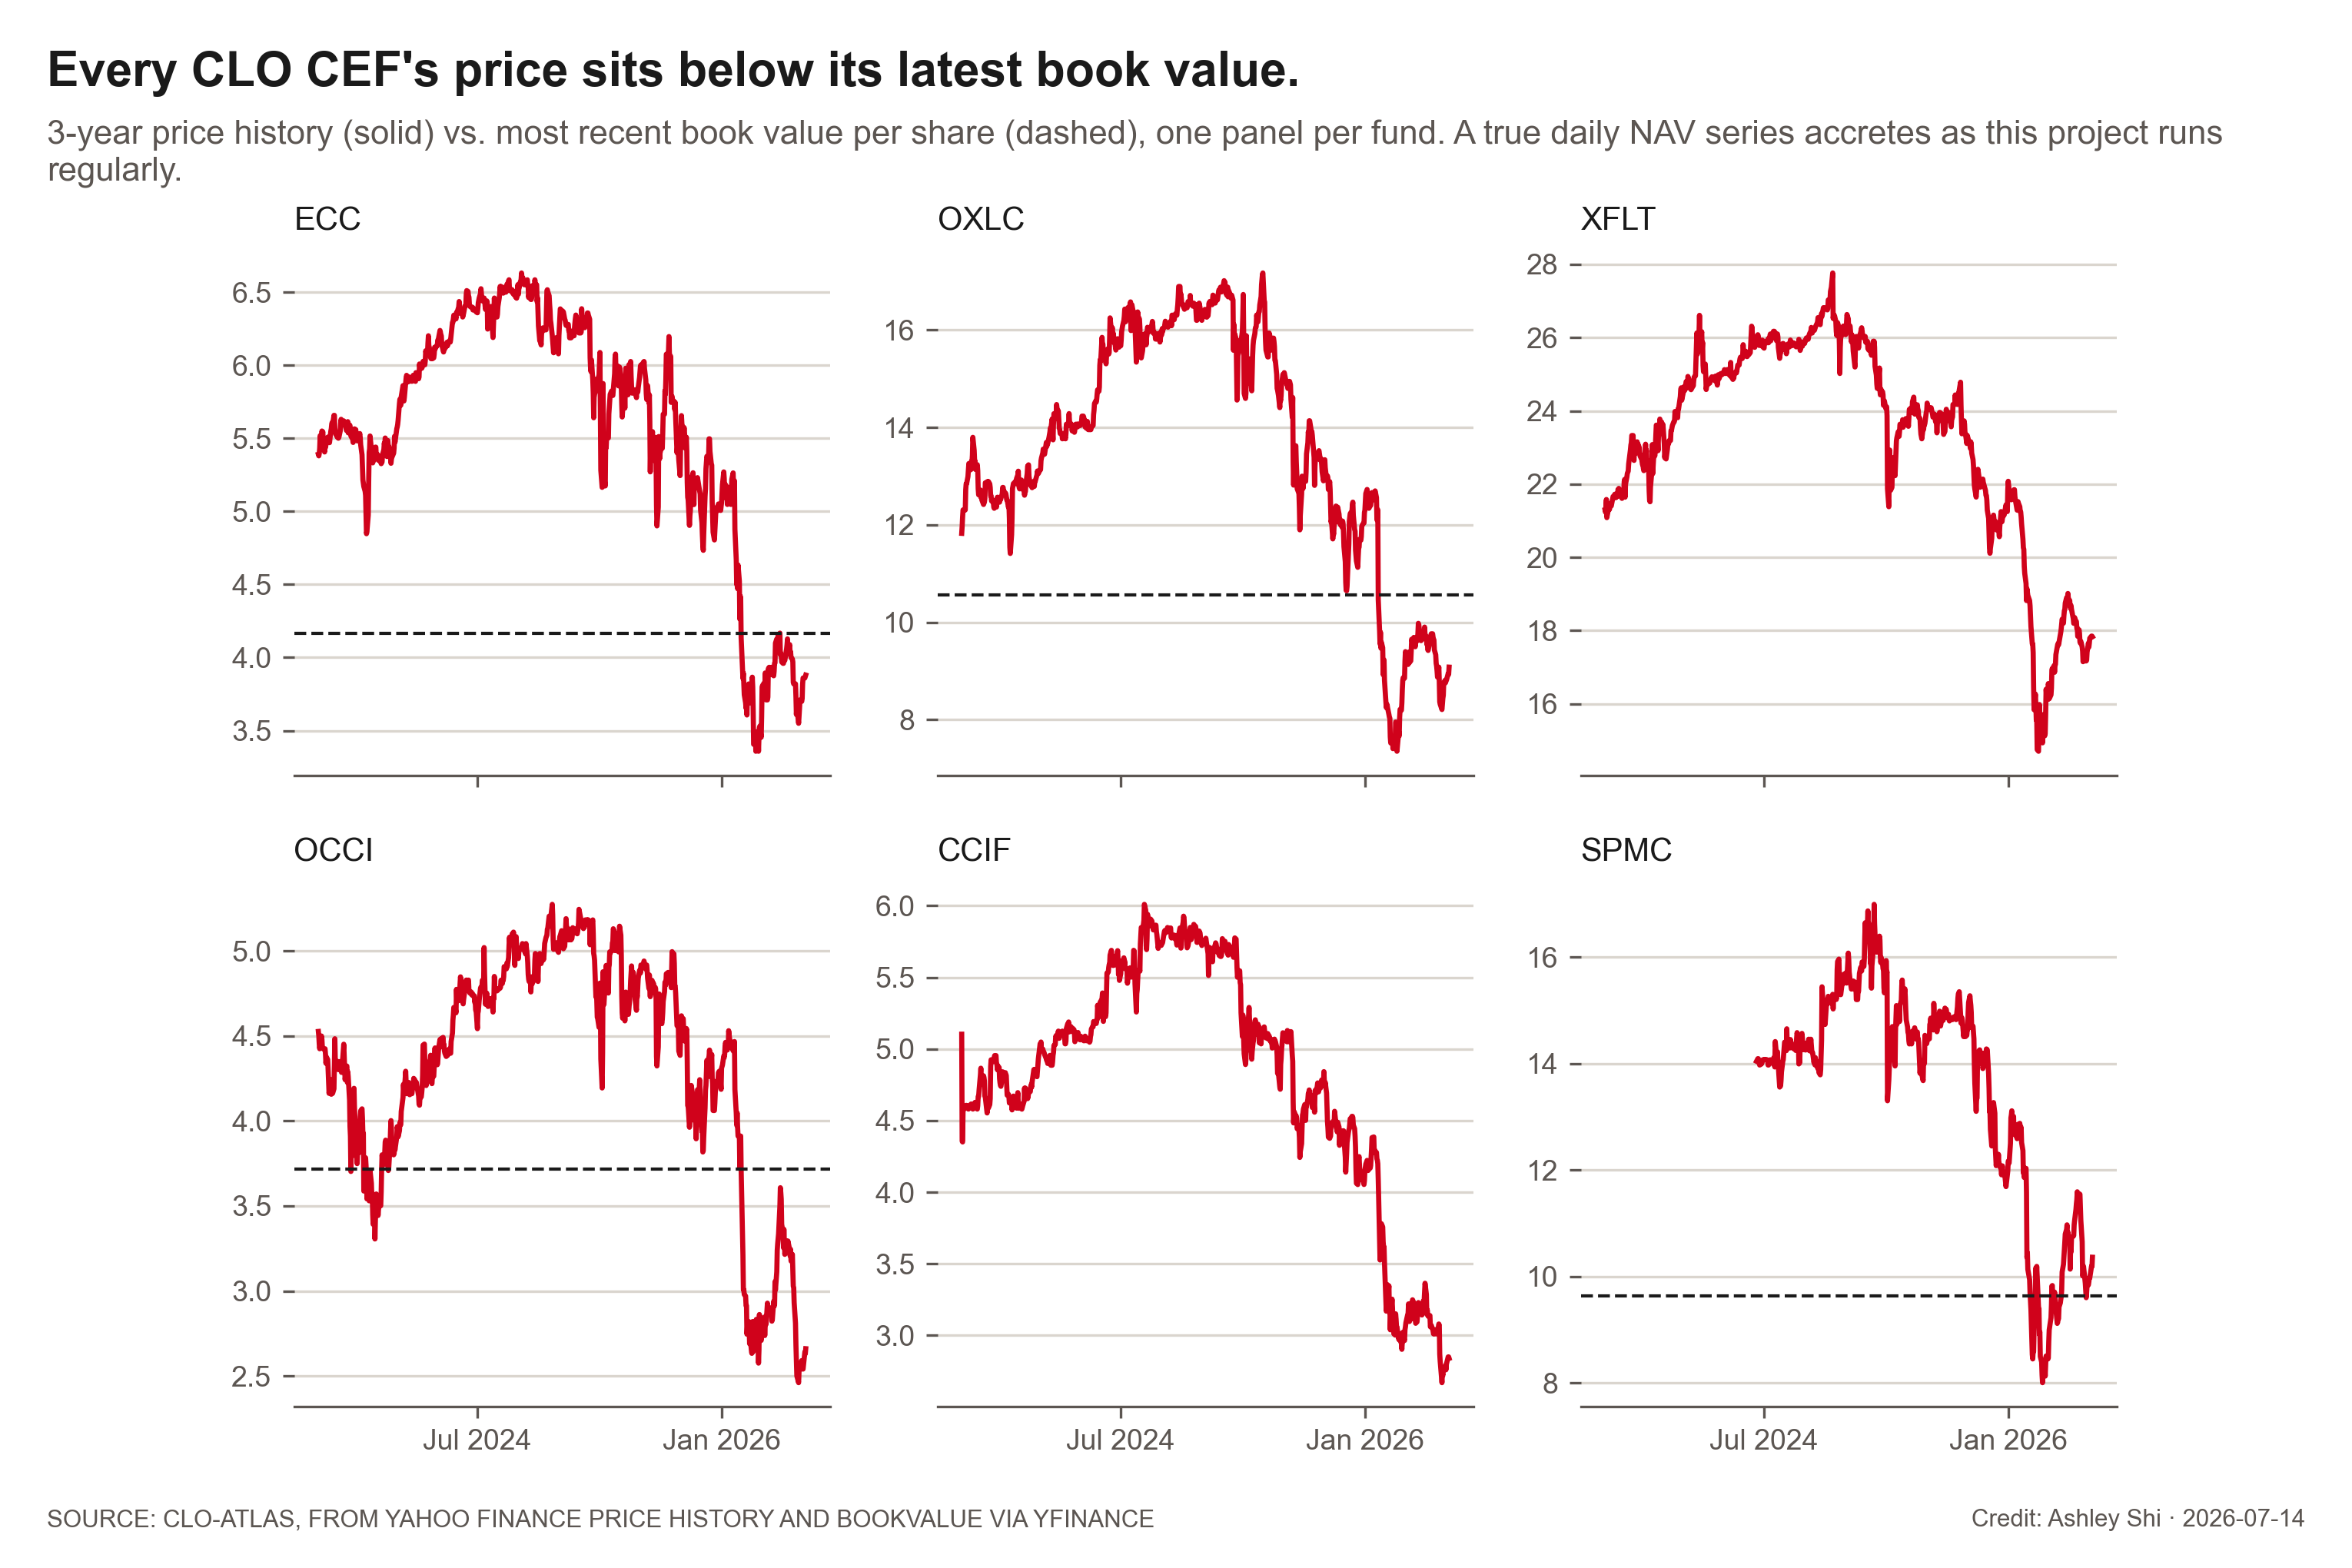

In [7]:
path = pathlib.Path("../figures") / "viz_price_vs_book_reference.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_price_vs_book_reference")


**VERIFIED**: 3-year adjusted-close price history per fund via yfinance, with the latest `bookValue` reading (dashed line) plotted as a reference — a proxy, since no free source publishes these funds' own daily NAV. Small multiples cover all six tickers (ECC, OXLC, XFLT, OCCI, CCIF, SPMC), and every panel's price line sits below its dashed book-value line. That gap independently confirms the discount shown in the snapshot bar chart above, and it puts a floor under how much of the "high yield" in these funds' distributions is return of shrinking capital rather than income.

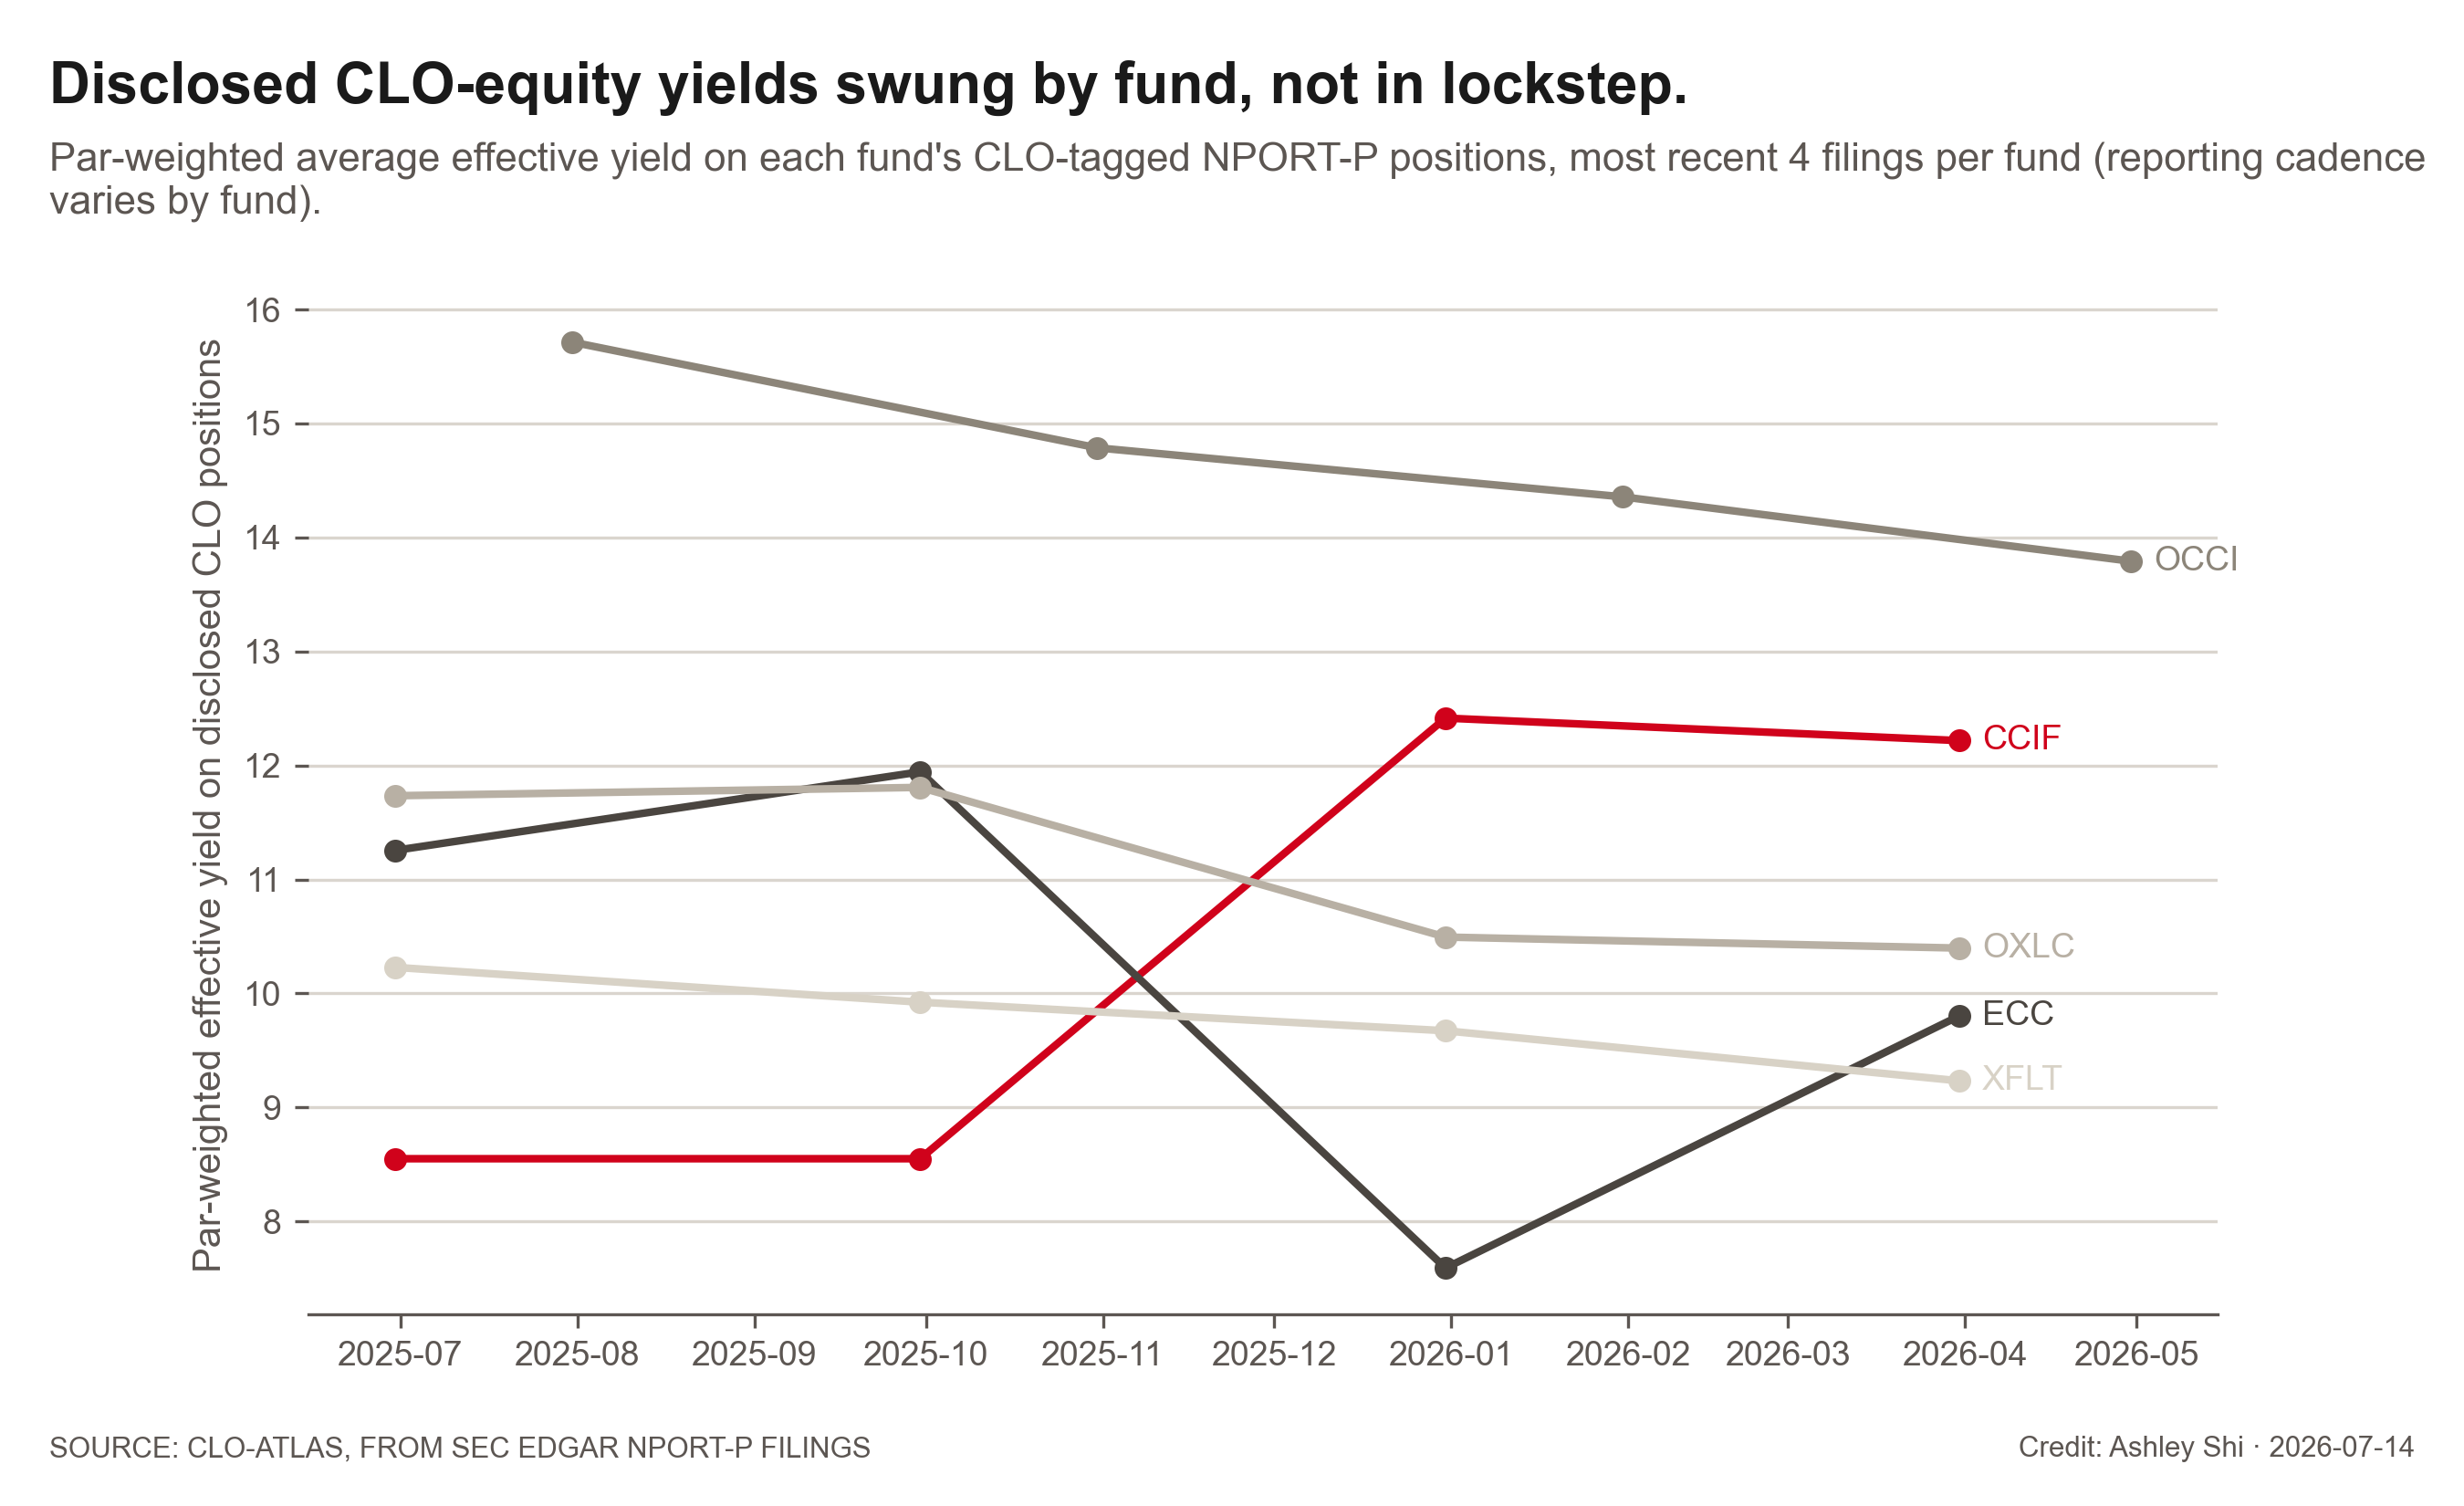

In [8]:
path = pathlib.Path("../figures") / "viz_weighted_yield_trend.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_weighted_yield_trend")


**VERIFIED**: par-weighted average effective yield on each fund's CLO-equity positions, computed from the most recent four SEC EDGAR NPORT-P quarterly filings per fund (reporting cadence varies by filer). Each line traces one fund's disclosed portfolio yield over time, directly labeled rather than boxed in a legend. The swings move fund by fund, not in lockstep, which matters for the asset-class pitch: CLO-equity return isn't one homogeneous number — it depends on which manager's book and vintage mix sits inside the wrapper an investor actually buys.